# Restaurant Tips Exploratory Data Analysis

**Author:** Shalynne Orth

## Research Question

How do party size, meal time, and day of the week relate to restaurant
tip amounts?

This notebook explores Seaborn's built-in `tips` dataset using Python,
pandas, and data visualizations.

In [25]:
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")

df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Section 2. Dataset Overview

The Seaborn `tips` dataset contains restaurant-bill information. Each row
represents one table's bill and tip. The dataset includes bill totals, tip
amounts, customer characteristics, meal time, day of week, and party size.

In [26]:
print("Dataset shape:", df.shape)

display(df.dtypes.to_frame(name="data_type"))
display(df.isnull().sum().to_frame(name="missing_values"))
display(df.describe(include="all").T)

Dataset shape: (244, 7)


,data_type
total_bill,float64
tip,float64
sex,category
smoker,category
day,category
time,category
size,int64


,missing_values
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
total_bill,244.0,NaN,NaN,NaN,19.785943,8.902412,3.07,13.3475,17.795,24.1275,50.81
tip,244.0,NaN,NaN,NaN,2.998279,1.383638,1.0,2.0,2.9,3.5625,10.0
sex,244,2,Male,157,NaN,NaN,NaN,NaN,NaN,NaN,NaN
smoker,244,2,No,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,244,4,Sat,87,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time,244,2,Dinner,176,NaN,NaN,NaN,NaN,NaN,NaN,NaN
size,244.0,NaN,NaN,NaN,2.569672,0.9511,1.0,2.0,2.0,3.0,6.0


### Initial Observations

The dataset contains 244 restaurant bills and 7 columns. There are no
missing values, so no rows need to be removed before this analysis.

The average bill is about $19.79, and the average tip is about $3.00.
Saturday is the most common day in the dataset, with 87 observations.
Dinner is the most common meal time, with 176 observations.

## Section 3. Review Numeric Distributions

This section examines the distributions of bill totals and tip amounts.
Histograms help show typical values, spread, and possible outliers.

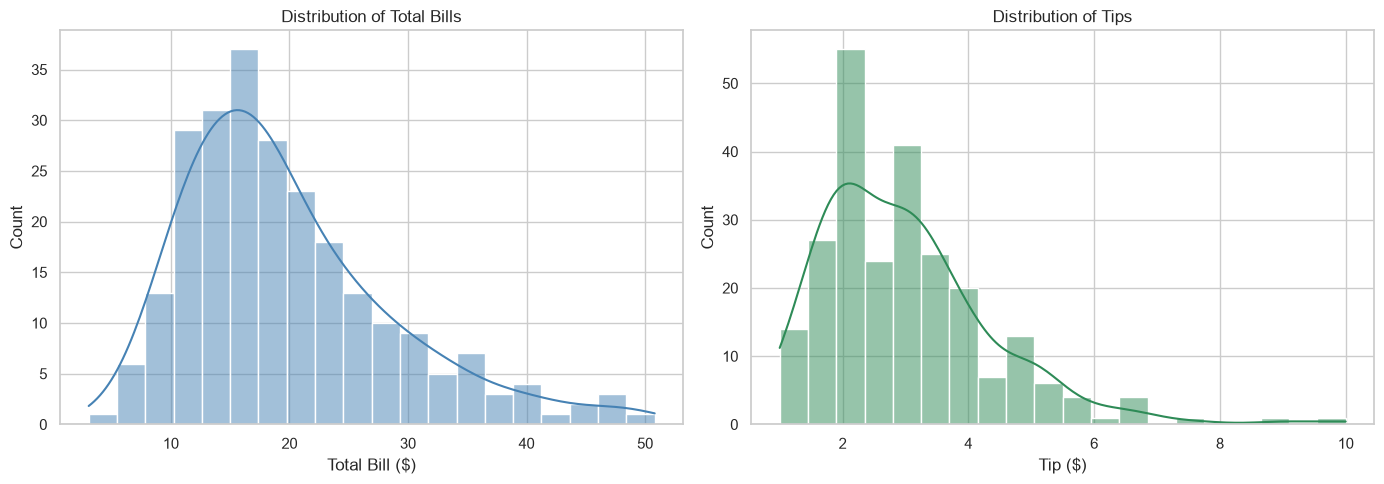

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df,
    x="total_bill",
    bins=20,
    kde=True,
    color="steelblue",
    ax=axes[0],
)
axes[0].set_title("Distribution of Total Bills")
axes[0].set_xlabel("Total Bill ($)")

sns.histplot(
    data=df,
    x="tip",
    bins=20,
    kde=True,
    color="seagreen",
    ax=axes[1],
)
axes[1].set_title("Distribution of Tips")
axes[1].set_xlabel("Tip ($)")

plt.tight_layout()
plt.show()

### Distribution Observations

Both total bills and tips are right-skewed. Most bills fall between about
$10 and $25, while most tips fall between about $2 and $4. A small number of
large bills and large tips create long right tails in both distributions.

## Section 4. Relationship Between Bill Total and Tip

This section investigates whether larger restaurant bills tend to receive
larger tips. It also compares the relationship between lunch and dinner.

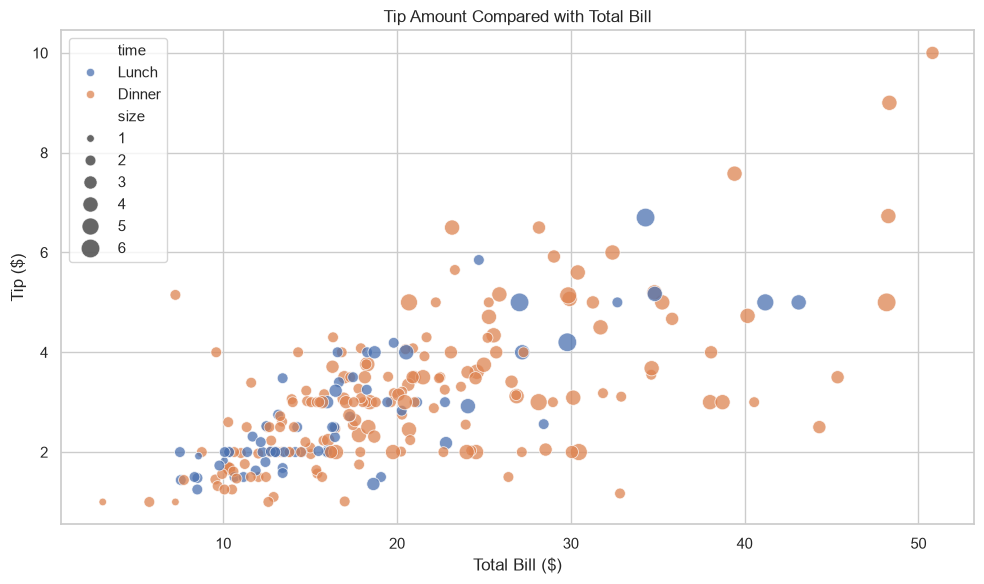

Correlation between total bill and tip: 0.68


In [28]:
df["tip_percent"] = (df["tip"] / df["total_bill"]) * 100

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip",
    hue="time",
    size="size",
    sizes=(30, 180),
    alpha=0.75,
)

plt.title("Tip Amount Compared with Total Bill")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.tight_layout()
plt.show()

correlation = df["total_bill"].corr(df["tip"])
print(f"Correlation between total bill and tip: {correlation:.2f}")

### Relationship Observation

Total bill and tip amount have a moderately strong positive correlation of
0.68. In general, larger bills receive larger tips. The scatter plot also
shows variation, meaning bill total is not the only factor related to tips.

## Section 5. Tip Percentage by Day and Meal Time

Tip amount usually rises with the bill total. Tip percentage provides a fairer
comparison because it shows the portion of each bill left as a tip.

count   mean  median
day  time                        
Thur Lunch      61  16.13   15.38
     Dinner      1  15.97   15.97
Fri  Lunch       7  18.88   18.77
     Dinner     12  15.89   14.47
Sat  Dinner     87  15.32   15.18
Sun  Dinner     76  16.69   16.11

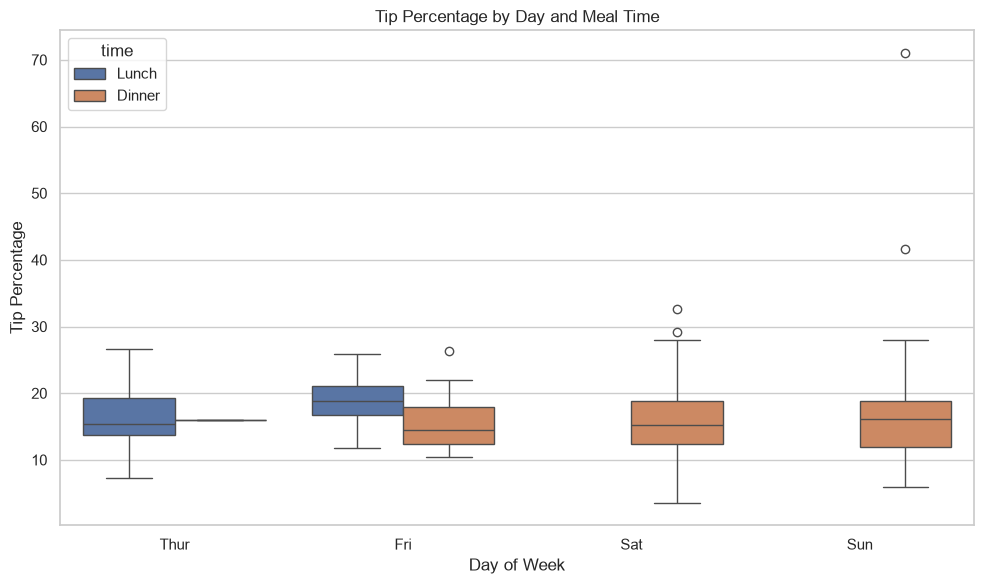

In [29]:
tip_summary = (
    df.groupby(["day", "time"], observed=True)["tip_percent"]
    .agg(["count", "mean", "median"])
    .round(2)
)

display(tip_summary)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="day",
    y="tip_percent",
    hue="time",
    order=["Thur", "Fri", "Sat", "Sun"],
)

plt.title("Tip Percentage by Day and Meal Time")
plt.xlabel("Day of Week")
plt.ylabel("Tip Percentage")
plt.tight_layout()
plt.show()

### Tip-Percentage Observations

Average tip percentages are fairly similar across the larger groups, ranging
from about 15% to 19%. Friday lunch has the highest average tip percentage,
but it includes only 7 observations, so that result should be interpreted
carefully.

Saturday and Sunday dinner have much larger sample sizes. Sunday includes two
unusually high tip-percentage outliers, which may be worth investigating in a
future analysis.

## Section 6. Tip Percentage by Party Size

This section compares tip percentages across party sizes to see whether larger
groups tend to leave a different percentage of the bill as a tip.

,count,mean,median
size,,,
1,4,21.73,20.28
2,156,16.57,15.61
3,38,15.22,15.93
4,37,14.59,14.67
5,5,14.15,12.14
6,4,15.62,16.29


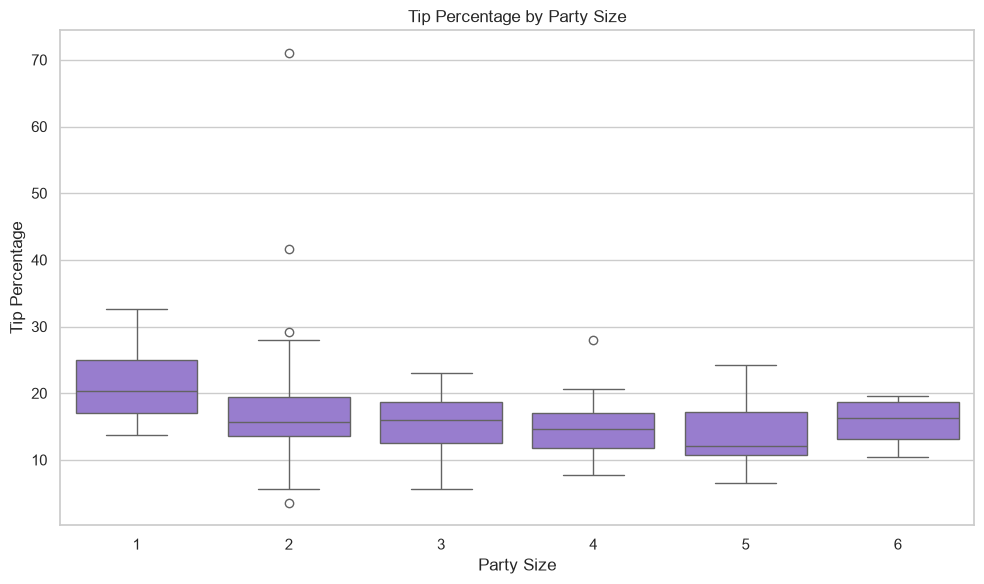

In [30]:
party_summary = (
    df.groupby("size", observed=True)["tip_percent"]
    .agg(["count", "mean", "median"])
    .round(2)
)

display(party_summary)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="size",
    y="tip_percent",
    color="mediumpurple",
)

plt.title("Tip Percentage by Party Size")
plt.xlabel("Party Size")
plt.ylabel("Tip Percentage")
plt.tight_layout()
plt.show()

### Party-Size Observations

Two-person parties make up most of the dataset, with 156 observations and an
average tip percentage of 16.57%. The one-person group has the highest average
tip percentage, but it has only 4 observations, so it is not reliable for a
strong conclusion.

Groups with 3 to 6 people have average tip percentages between about 14% and
16%. The two-person group includes several unusually high tip-percentage
outliers.

## Section 7. Conclusions and Next Steps

### Summary of Findings

This analysis explored 244 restaurant bills from Seaborn's built-in `tips`
dataset. The dataset contains 7 columns and has no missing values.

Total bill and tip amount have a moderately strong positive correlation of
0.68. Larger bills generally receive larger tips, although there is meaningful
variation among individual bills.

Tip percentages are generally similar across the larger day and meal-time
groups. Party size may be related to tip percentage, but small groups have too
few observations for strong conclusions.

### Data Source

The data was loaded with Seaborn's built-in `tips` dataset using
`sns.load_dataset("tips")`. Each row represents one restaurant bill and
includes the bill total, tip, meal time, day of week, and party size.

### Next Analytical Step

A useful next step would be to build a statistical model that estimates tip
percentage using bill total, party size, meal time, day of week, and smoker
status. This could show which factors remain related to tipping after the
other variables are considered.